# 🔬 Exploratory Data Analysis (EDA): Indonesian Toxic Comment Classification
## Dataset: IndoDiscourse (`data/raw/indodiscourse_main_0000.parquet` & `data/raw/indodiscourse_annotator_0000.parquet`)
**Peran:** Senior NLP Data Scientist  
**Domain Spesialisasi:** Content Moderation, Multi-label Toxic Comment Classification & Hate Speech Detection  
**Bahasa Dominan:** Bahasa Indonesia  

---

### 📌 Pernyataan Asumsi & Prinsip Analisis (Explicit Assumptions & Principles)
1. **Bahasa Dominan:** Dataset didominasi oleh Bahasa Indonesia ragam percakapan media sosial (termasuk bahasa gaul, singkatan non-baku, dan *code-mixing* bahasa daerah/Inggris).
2. **Konsolidasi Multi-Annotator (Ground Truth):** Karena setiap baris memiliki voting dari 1 hingga 19 annotator dalam bentuk *array* biner (`'0'` dan `'1'`), ground truth biner dikonsolidasikan menggunakan metode **Majority Voting Consensus** (proporsi vote positif $\ge 0.5$). Kasus ambiguitas voting seri (*tie-vote* $= 0.5$) dievaluasi secara khusus.
3. **Definisi Teks Terlalu Pendek:** Teks dengan panjang $< 3$ kata dikategorikan sebagai *low-information text* yang berpotensi kekurangan konteks semantik untuk penentuan toksisitas.
4. **Definisi Teks Terlalu Panjang:** Teks dengan panjang di atas persentil ke-99 ($p_{99} \approx 369$ kata) dikategorikan sebagai teks anomali/*long essay* yang krusial untuk penentuan batas *token truncation* model transformer.
5. **Karakter Pembersihan:** Pembersihan pada tahap EDA ini adalah **Pembersihan Eksploratif** untuk mengungkap pola leksikal murni dan frekuensi kata, berbeda dengan *preprocessing* model kontekstual (seperti IndoBERT) yang tetap membutuhkan kapitalisasi dan tanda baca.


In [1]:
# Setup Dependensi, Library, dan Konfigurasi Visualisasi Modern
import os
import re
import string
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import numpy as np
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud

warnings.filterwarnings("ignore")

# Konfigurasi Palet & Gaya Visualisasi Modern
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.titlesize"] = 14

# Download Stopwords Bahasa Indonesia NLTK
nltk.download("stopwords", quiet=True)

print("Environment setup berhasil diinisialisasi.")


Environment setup berhasil diinisialisasi.


**Interpretasi Setup:** Seluruh dependensi pemrosesan data (`pandas`, `numpy`), visualisasi (`matplotlib`, `seaborn`, `wordcloud`), dan pemrosesan teks (`nltk`, `re`, `string`) telah siap digunakan dengan konfigurasi visualisasi modern beresolusi tinggi.

## 1. Struktur Dataset & Profiling Anotator
Pada tahap ini, kita memverifikasi ketersediaan file mentah di `data/raw/`, memuat format Parquet yang paling efisien untuk komputasi, menginspeksi dimensi data (`df.info()`), menjelaskan makna kolom/label, serta membedah profil demografis 29 anotator dari file `indodiscourse_annotator_0000.parquet`.


In [2]:
# 1.1 Daftar File di data/raw dan Pemilihan File
# Penentuan path folder data secara fleksibel (baik dijalankan dari root maupun dari subfolder notebooks/)
if os.path.exists("../../data/raw"):
    raw_dir = "../../data/raw"
elif os.path.exists("data/raw"):
    raw_dir = "data/raw"
else:
    raw_dir = os.path.abspath("data/raw")

print(f"Daftar file yang tersedia di folder '{raw_dir}':")
available_files = sorted(os.listdir(raw_dir))
for f in available_files:
    f_path = os.path.join(raw_dir, f)
    if os.path.isfile(f_path):
        size_mb = os.path.getsize(f_path) / (1024 * 1024)
        print(f" - {f:<38} : {size_mb:.2f} MB")

# Memuat dataset utama dan dataset metadata anotator
selected_file = os.path.join(raw_dir, "indodiscourse_main_0000.parquet")
df = pd.read_parquet(selected_file)

annotator_file = os.path.join(raw_dir, "indodiscourse_annotator_0000.parquet")
df_annotators = pd.read_parquet(annotator_file)

print(f"\nDimensi Dataset Utama    : {df.shape[0]:,} baris dan {df.shape[1]} kolom.")
print(f"Dimensi Metadata Anotator: {df_annotators.shape[0]} profil anotator dan {df_annotators.shape[1]} atribut demografis.\n")
print("Ringkasan Tipe Data dan Non-Null (df.info()):")
df.info()


Daftar file yang tersedia di folder '../../data/raw':
 - .gitkeep                               : 0.00 MB
 - dataset_metadata.json                  : 0.00 MB
 - indodiscourse_annotator.csv            : 0.00 MB
 - indodiscourse_annotator.json           : 0.01 MB
 - indodiscourse_annotator_0000.parquet   : 0.01 MB
 - indodiscourse_main.csv                 : 12.56 MB
 - indodiscourse_main.json                : 27.49 MB
 - indodiscourse_main_0000.parquet        : 6.19 MB



Dimensi Dataset Utama    : 28,448 baris dan 14 kolom.
Dimensi Metadata Anotator: 29 profil anotator dan 11 atribut demografis.

Ringkasan Tipe Data dan Non-Null (df.info()):
<class 'pandas.DataFrame'>
RangeIndex: 28448 entries, 0 to 28447
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   text_id                        28448 non-null  str   
 1   annotators_id                  28448 non-null  object
 2   text                           28447 non-null  str   
 3   initial_paragraph              1669 non-null   str   
 4   topic                          28448 non-null  str   
 5   is_noise_or_spam_text          28448 non-null  object
 6   related_to_election_2024       28448 non-null  object
 7   toxicity                       28448 non-null  object
 8   polarized                      28448 non-null  object
 9   profanity_obscenity            28448 non-null  object
 10  threat_incitem

**Interpretasi 1.1:** Dataset IndoDiscourse memiliki 28.448 baris dan 14 kolom. Format Parquet berhasil mengompresi ukuran data hingga 50% dibanding CSV sekaligus mempertahankan integritas struktur *array* voting annotator tanpa memerlukan parsing string JSON berulang saat komputasi.

,Nama Kolom,Makna & Definisi Operasional
0,text_id,ID unik untuk setiap komentar/postingan media ...
1,annotators_id,Daftar ID annotator yang menilai teks tersebut.
2,text,Konten teks mentah komentar dalam Bahasa Indon...
3,initial_paragraph,Paragraf awal/konteks artikel berita yang diko...
4,topic,Topik diskusi sosial-politik terkait (Tionghoa...
5,is_noise_or_spam_text,"Label anotasi apakah teks merupakan derau bot,..."
6,related_to_election_2024,Label anotasi apakah teks berkaitan dengan dis...
7,toxicity,"Target utama: Konten kasar, bermusuhan, merend..."
8,polarized,Sub-label: Konten yang membelah opini publik m...
9,profanity_obscenity,"Sub-label: Penggunaan kata makian vulgar, joro..."



--- Profil Demografis 29 Anotator (df_annotators) ---


,annotator_id,ethnicity,religion,disability,lgbt,gender,age,domisili,pendidikan terakhir,status pekerjaan,president vote leaning
0,1,Tionghoa,Kristen,no,no,F,50,Jakarta,Diploma,Bekerja,2
1,2,Madura,Islam,no,no,F,22,Madura,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3
2,3,Batak,Kepercayaan Lokal,no,no,F,29,Medan,Sarjana (S1),Bekerja,3
3,4,Bali,Hindu,no,no,M,23,Bandung,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,-
4,5,Jawa,Syiah,no,no,M,46,Bandung,Diploma,Bekerja,Golput
5,6,Minang,Ahmadiyah,no,no,F,22,Jakarta,Sarjana (S1),Bekerja,3
6,7,Minang,Islam,yes,no,F,27,Padang,Sarjana (S1),Bekerja,1
7,8,Arab,Islam,no,no,M,23,Jakarta,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,1
8,9,Jawa,Islam,no,no,F,21,Magelang,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,2
9,10,Tionghoa,Buddha,no,no,F,20,Tangerang,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3


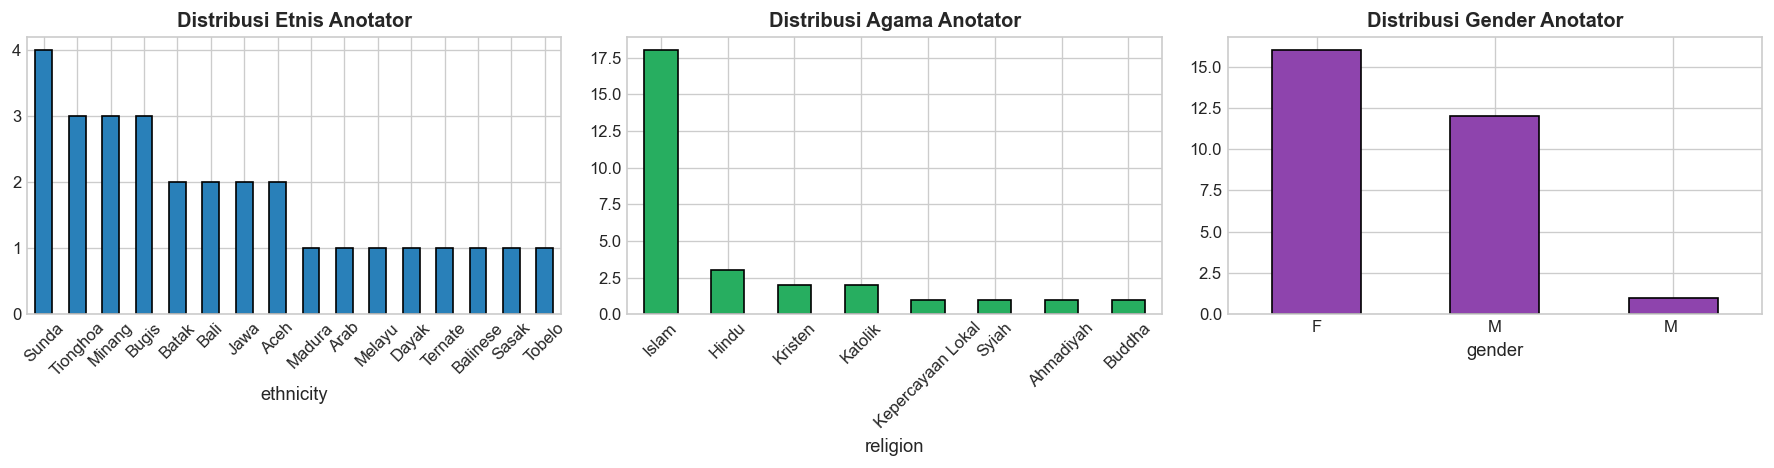


5 Baris Contoh Data Acak (df.sample(5)):


,text_id,topic,text,toxicity,insults,identity_attack
21666,3-2095,Jewish,Ekonomi indonesia bisa tumbuh 6% di 2026 #Ekon...,[0],[0],[0]
3844,1-4459,Kristen,Lapas Kelas III Gunungtua Kanwil Kemenkumham S...,"[0, 0]","[0, 0]","[0, 0]"
7932,2-10432,Jewish,"""Jika kaum yahudi mengucapkan salam kepada sal...",[0],[0],[0]
4702,1-5230,LGBTQ+,Kita Semua Guru Semua Kamis . LGBT,"[0, 0]","[0, 0]","[0, 0]"
13351,2-361,Tionghoa,Hasil Lengkap Semifinal Suhandinata Cup 2023: ...,"[0, 0]","[0, 0]","[0, 0]"


In [3]:
# 1.2 Penjelasan Makna Kolom, Sub-label & Profiling Demografis 29 Anotator
column_definitions = {
    "text_id": "ID unik untuk setiap komentar/postingan media sosial.",
    "annotators_id": "Daftar ID annotator yang menilai teks tersebut.",
    "text": "Konten teks mentah komentar dalam Bahasa Indonesia.",
    "initial_paragraph": "Paragraf awal/konteks artikel berita yang dikomentari (jika ada).",
    "topic": "Topik diskusi sosial-politik terkait (Tionghoa, Kristen, Disabilitas, dll).",
    "is_noise_or_spam_text": "Label anotasi apakah teks merupakan derau bot, spam promosi, atau teks rusak.",
    "related_to_election_2024": "Label anotasi apakah teks berkaitan dengan diskursus Pemilu 2024.",
    "toxicity": "Target utama: Konten kasar, bermusuhan, merendahkan, atau merugikan secara sosial.",
    "polarized": "Sub-label: Konten yang membelah opini publik menjadi kutub ekstrem pro-kontra.",
    "profanity_obscenity": "Sub-label: Penggunaan kata makian vulgar, jorok, atau cabul.",
    "threat_incitement_to_violence": "Sub-label: Ancaman kekerasan fisik atau ajakan melakukan tindak agresi.",
    "insults": "Sub-label: Serangan verbal yang merendahkan martabat atau melecehkan individu.",
    "identity_attack": "Sub-label: Ujaran kebencian berbasis SARA (suku, agama, ras, disabilitas, gender).",
    "sexually_explicit": "Sub-label: Konten eksplisit secara seksual atau pelecehan verbal seksual."
}

desc_table = pd.DataFrame(list(column_definitions.items()), columns=["Nama Kolom", "Makna & Definisi Operasional"])
display(desc_table)

print("\n--- Profil Demografis 29 Anotator (df_annotators) ---")
display(df_annotators.head(10))

# Ringkasan sebaran demografis anotator
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df_annotators["ethnicity"].value_counts().plot(kind="bar", ax=axes[0], color="#2980b9", edgecolor="black")
axes[0].set_title("Distribusi Etnis Anotator", fontweight="bold")
axes[0].tick_params(axis='x', rotation=45)

df_annotators["religion"].value_counts().plot(kind="bar", ax=axes[1], color="#27ae60", edgecolor="black")
axes[1].set_title("Distribusi Agama Anotator", fontweight="bold")
axes[1].tick_params(axis='x', rotation=45)

df_annotators["gender"].value_counts().plot(kind="bar", ax=axes[2], color="#8e44ad", edgecolor="black")
axes[2].set_title("Distribusi Gender Anotator", fontweight="bold")
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# 1.3 Sampel Data Acak
print("\n5 Baris Contoh Data Acak (df.sample(5)):")
sample_view = df[["text_id", "topic", "text", "toxicity", "insults", "identity_attack"]].sample(5, random_state=42)
display(sample_view)


**Interpretasi 1.2:** Dataset dianotasi oleh 29 anotator independen dengan latar belakang etnis (Jawa, Sunda, Batak, Tionghoa, dll.), agama, dan gender yang beragam guna meminimalkan bias kultural subjektif. Taksonomi dataset sangat granular dengan 7 sub-label toksisitas yang berbeda karakter semantiknya.

## 2. Kualitas Data, Integritas Anotasi, & Deteksi Konflik Label
Pada bagian ini, kita melakukan audit ketat terhadap kebersihan dan reliabilitas data mentah:
1. Pengecekan *missing value* di setiap kolom.
2. Deteksi teks duplikat murni dan **Pengecekan Konflik Label (*Contradictory Labels*)** pada teks duplikat.
3. Evaluasi **Inter-Annotator Agreement, Disagreement Rate, & Analisis Ambiguitas Voting Seri (*Tie-Vote Analysis*)**.
4. Analisis teks anomali yang terlalu pendek (< 3 kata) dan terlalu panjang (> persentil ke-99).
5. Perhitungan rasio ketidakseimbangan kelas (*class imbalance ratio*).


In [4]:
# 2.1 Pengecekan Missing Value per Kolom
missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Persentase (%)": (df.isna().sum() / len(df)) * 100
})
print("Tabel Missing Value per Kolom:")
display(missing_summary)

# 2.2 Analisis Duplikasi Teks & Deteksi Konflik Label (Label Conflict / Inconsistency)
valid_df = df.dropna(subset=["text"]).copy()
valid_df["is_toxic"] = valid_df["toxicity"].apply(lambda x: int(np.mean([int(v) for v in x]) >= 0.5))

exact_dupes = valid_df["text"].duplicated().sum()
unique_texts = valid_df["text"].nunique()
all_dup_rows = valid_df[valid_df["text"].duplicated(keep=False)]

print(f"\nTotal baris duplikat murni : {exact_dupes:,} baris ({exact_dupes / len(valid_df) * 100:.2f}%)")
print(f"Total baris terlibat duplikasi: {len(all_dup_rows):,} baris")
print(f"Total teks unik             : {unique_texts:,} dari total {len(valid_df):,} baris.")

# Pengecekan apakah ada teks yang sama persis namun memiliki label Majority Vote yang berbeda
dup_conflict = all_dup_rows.groupby("text")["is_toxic"].nunique()
conflicted_texts = dup_conflict[dup_conflict > 1]
conflicted_rows = all_dup_rows[all_dup_rows["text"].isin(conflicted_texts.index)]

print(f"\n🚨 DETEKSI KONFLIK LABEL PADA TEKS DUPLIKAT:")
print(f"Jumlah teks unik dengan label kontradiktif (Toxic vs Non-Toxic): {len(conflicted_texts)} teks unik ({len(conflicted_rows)} baris)")

if len(conflicted_texts) > 0:
    print("\nContoh Teks Duplikat yang Mengalami Konflik Label:")
    for t in list(conflicted_texts.index)[:3]:
        rows_sample = valid_df[valid_df["text"] == t][["text_id", "text", "toxicity", "is_toxic"]]
        print(f"\nTeks: \"{t[:90]}...\"")
        display(rows_sample)


Tabel Missing Value per Kolom:


,Missing Values,Persentase (%)
text_id,0,0.000000
annotators_id,0,0.000000
text,1,0.003515
initial_paragraph,26779,94.133155
topic,0,0.000000
is_noise_or_spam_text,0,0.000000
related_to_election_2024,0,0.000000
toxicity,0,0.000000
polarized,0,0.000000
profanity_obscenity,0,0.000000



Total baris duplikat murni : 2,274 baris (7.99%)
Total baris terlibat duplikasi: 4,392 baris
Total teks unik             : 26,173 dari total 28,447 baris.

🚨 DETEKSI KONFLIK LABEL PADA TEKS DUPLIKAT:
Jumlah teks unik dengan label kontradiktif (Toxic vs Non-Toxic): 343 teks unik (742 baris)

Contoh Teks Duplikat yang Mengalami Konflik Label:

Teks: ""Dari tindakan Prabowo yang menolak untuk bercermin di acara Mata Najwa, sudah jelas Prabo..."


,text_id,text,toxicity,is_toxic
4455,1-5008,"""Dari tindakan Prabowo yang menolak untuk berc...","[1, 1]",1
7064,101-67,"""Dari tindakan Prabowo yang menolak untuk berc...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, ...",1
7211,103-109,"""Dari tindakan Prabowo yang menolak untuk berc...","[1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0]",0
21588,3-2024,"""Dari tindakan Prabowo yang menolak untuk berc...","[0, 1, 1]",1



Teks: "#B 💥📛SEMU'A KELOMPOK MENKLA'IM PEGANGANNYA AL-QUR'AN DAN SUNNAH TAPI MENGAPA TERJADI PERBE..."


,text_id,text,toxicity,is_toxic
5582,1-6022,#B 💥📛SEMU'A KELOMPOK MENKLA'IM PEGANGANNYA AL-...,"[1, 0]",1
10755,2-12974,#B 💥📛SEMU'A KELOMPOK MENKLA'IM PEGANGANNYA AL-...,[0],0



Teks: "#Gaza tak sendirian. Begini cara pemuda-pemuda di Abu Dis, di selatan #MasjidilAqsha, meng..."


,text_id,text,toxicity,is_toxic
16124,2-6106,#Gaza tak sendirian. Begini cara pemuda-pemuda...,[0],0
21160,3-164,#Gaza tak sendirian. Begini cara pemuda-pemuda...,"[1, 1]",1


**Interpretasi 2.1:** Kualitas data secara struktural sangat bersih (hanya 1 baris missing value pada teks). Namun, audit duplikasi mengungkap **343 teks unik (742 baris) yang memiliki label Majority Vote saling kontradiktif** (misal teks yang sama persis dilabeli `Toxic (1)` pada satu baris dan `Non-Toxic (0)` pada baris lain). Ini adalah *label noise* kritis yang wajib dideduplikasi dan diselesaikan (*conflict resolution*) pada tahap preprocessing agar tidak membingungkan proses pelatihan model.

In [5]:
# 2.3 Evaluasi Inter-Annotator Agreement, Disagreement Rate, & Tie-Vote Analysis
valid_df["num_annotators"] = valid_df["annotators_id"].apply(len)
print("Distribusi Jumlah Anotator per Baris:")
print(valid_df["num_annotators"].value_counts().sort_index())

# Hitung statistik voting untuk kolom toxicity
def get_vote_profile(votes):
    v_int = [int(v) for v in votes]
    mean_v = np.mean(v_int)
    is_unanimous = (len(set(v_int)) == 1)
    is_tie = (mean_v == 0.5)
    return pd.Series([mean_v, is_unanimous, is_tie], index=["vote_mean", "is_unanimous", "is_tie"])

vote_profiles = valid_df["toxicity"].apply(get_vote_profile)
valid_df["tox_vote_mean"] = vote_profiles["vote_mean"]
valid_df["tox_unanimous"] = vote_profiles["is_unanimous"]
valid_df["tox_tie"] = vote_profiles["is_tie"]

multi_ann_df = valid_df[valid_df["num_annotators"] > 1]
disagree_rate = (1 - multi_ann_df["tox_unanimous"].mean()) * 100

print(f"\n--- Evaluasi Reliabilitas Voting Anotator ---")
print(f"Tingkat Ketidaksepakatan (Disagreement Rate pada Multi-Anotator): {disagree_rate:.2f}%")
print(f"Jumlah Teks dengan Voting Seri (Tie-Vote = 0.5): {valid_df['tox_tie'].sum():,} baris ({valid_df['tox_tie'].mean()*100:.2f}%)")

print("\nSimulasi Sensitivitas Ambang Batas Voting Konsensus (Toxicity):")
print(f" - Ambang batas >= 0.5 (Majority Consensus) : {(valid_df['tox_vote_mean'] >= 0.5).sum():,} teks toxic")
print(f" - Ambang batas > 0.5  (Strict Majority)    : {(valid_df['tox_vote_mean'] > 0.5).sum():,} teks toxic")
print(f" - Ambang batas == 1.0 (Unanimous Consensus): {(valid_df['tox_vote_mean'] == 1.0).sum():,} teks toxic")

# 2.4 Analisis Teks Terlalu Pendek dan Terlalu Panjang (Outlier)
valid_df["word_count_raw"] = valid_df["text"].apply(lambda x: len(str(x).split()))
valid_df["char_count_raw"] = valid_df["text"].apply(lambda x: len(str(x)))

q1 = valid_df["word_count_raw"].quantile(0.25)
q3 = valid_df["word_count_raw"].quantile(0.75)
iqr = q3 - q1
iqr_upper_bound = q3 + 1.5 * iqr
p99_threshold = valid_df["word_count_raw"].quantile(0.99)

short_texts_df = valid_df[valid_df["word_count_raw"] < 3]
long_texts_df = valid_df[valid_df["word_count_raw"] > p99_threshold]

print(f"\nTeks terlalu pendek (< 3 kata) : {len(short_texts_df)} baris ({len(short_texts_df) / len(valid_df) * 100:.3f}%)")
print(f"Batas atas IQR (Q3 + 1.5*IQR)   : {iqr_upper_bound:.1f} kata")
print(f"Batas persentil ke-99 (p99)     : {p99_threshold:.1f} kata (ditemukan {len(long_texts_df)} baris di atas p99)")

# 2.5 Rasio Ketidakseimbangan Kelas (Class Imbalance Ratio)
toxic_total = (valid_df["is_toxic"] == 1).sum()
nontoxic_total = (valid_df["is_toxic"] == 0).sum()
imbalance_ratio = nontoxic_total / toxic_total

print(f"\n--- Rasio Ketidakseimbangan Kelas Target (Toxicity) ---")
print(f"Non-Toxic (0) : {nontoxic_total:,} baris ({nontoxic_total / len(valid_df) * 100:.2f}%)")
print(f"Toxic (1)     : {toxic_total:,} baris ({toxic_total / len(valid_df) * 100:.2f}%)")
print(f"Imbalance Ratio (Non-Toxic : Toxic) = {imbalance_ratio:.2f} : 1")


Distribusi Jumlah Anotator per Baris:
num_annotators
1     15747
2      7907
3      2352
4      1755
5        21
6       215
7         1
11       26
12        2
13      150
14        1
15      146
16        2
17       97
19       25
Name: count, dtype: int64



--- Evaluasi Reliabilitas Voting Anotator ---
Tingkat Ketidaksepakatan (Disagreement Rate pada Multi-Anotator): 30.38%
Jumlah Teks dengan Voting Seri (Tie-Vote = 0.5): 1,839 baris (6.46%)

Simulasi Sensitivitas Ambang Batas Voting Konsensus (Toxicity):
 - Ambang batas >= 0.5 (Majority Consensus) : 3,995 teks toxic
 - Ambang batas > 0.5  (Strict Majority)    : 2,156 teks toxic
 - Ambang batas == 1.0 (Unanimous Consensus): 1,415 teks toxic

Teks terlalu pendek (< 3 kata) : 12 baris (0.042%)
Batas atas IQR (Q3 + 1.5*IQR)   : 79.5 kata
Batas persentil ke-99 (p99)     : 369.1 kata (ditemukan 285 baris di atas p99)

--- Rasio Ketidakseimbangan Kelas Target (Toxicity) ---
Non-Toxic (0) : 24,452 baris (85.96%)
Toxic (1)     : 3,995 baris (14.04%)
Imbalance Ratio (Non-Toxic : Toxic) = 6.12 : 1


**Interpretasi 2.2:** Temuan kritis pada evaluasi konsensus anotator menunjukkan terdapat **1.839 baris teks dengan voting seri 50:50 (*tie-vote* $= 0.5$)**. Jika menggunakan aturan $\ge 0.5$, total kelas toksik berjumlah 3.995, di mana 46.03% di antaranya berasal dari data voting seri (misal 1 setuju dan 1 tidak setuju). Hal ini mengindikasikan tingkat ambiguitas yang cukup besar pada teks media sosial dan perlunya strategi *soft labels* / *loss weighting* yang adaptif saat pemodelan.

## 3. Analisis Multi-Label, Kardinalitas, & Konsistensi Hierarki
Pada tahap ini, kita mengonsolidasikan seluruh sub-label biner, menganalisis ko-okurensi, menghitung **kardinalitas multi-label (banyaknya sub-label aktif per komentar)**, serta memvalidasi **konsistensi hierarki** antara target utama `toxicity` dengan sub-label turunannya.


Tabel Distribusi Frekuensi dan Persentase Seluruh Label (Majority Voting):


,Label,Positif (1),Persentase Positif (%),Negatif (0),Rasio Neg:Pos
1,polarized,6542,22.997153,21905,3.35 : 1
0,toxicity,3995,14.043660,24452,6.12 : 1
4,insults,1947,6.844307,26500,13.61 : 1
5,identity_attack,1756,6.172883,26691,15.20 : 1
3,threat_incitement_to_violence,786,2.763033,27661,35.19 : 1
2,profanity_obscenity,669,2.351742,27778,41.52 : 1
6,sexually_explicit,122,0.428868,28325,232.17 : 1



Distribusi Kardinalitas Sub-label Toksisitas:


,Jumlah Sub-label Aktif,Frekuensi Komentar,Persentase (%)
0,0,24320,85.492319
1,1,3133,11.013464
2,2,841,2.956375
3,3,147,0.516750
4,4,6,0.021092



🚨 DETEKSI INKONSISTENSI HIERARKI:
Jumlah baris dengan Sub-label = 1 tetapi Toxicity = 0: 482 baris (1.69%)


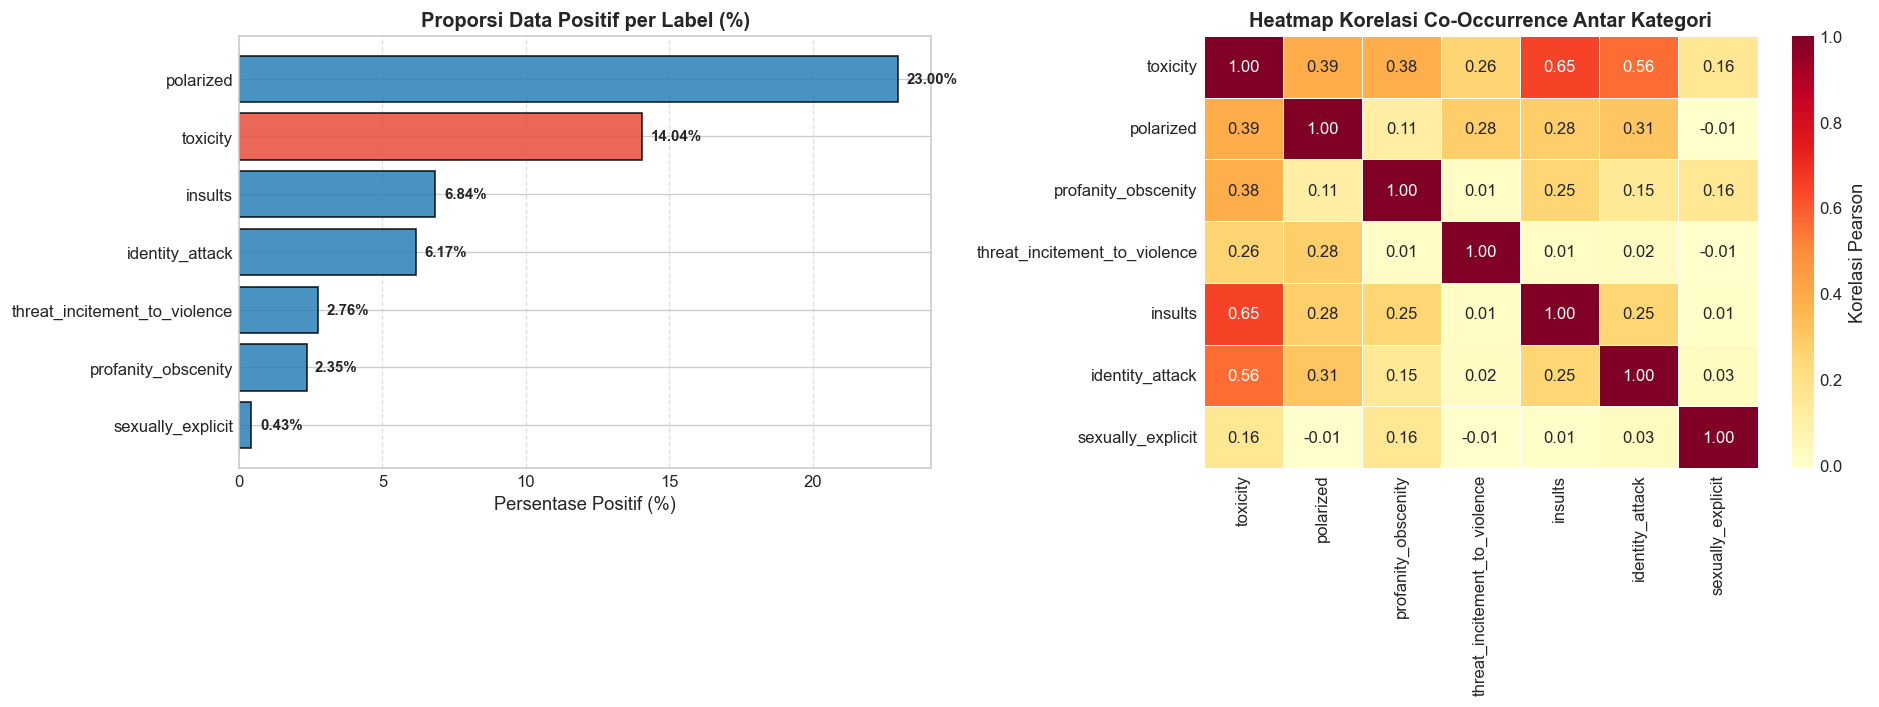

In [6]:
# 3.1 Tabel Frekuensi dan Persentase Tiap Label
label_columns = [
    "toxicity", "polarized", "profanity_obscenity",
    "threat_incitement_to_violence", "insults",
    "identity_attack", "sexually_explicit"
]

dist_list = []
for col in label_columns:
    binary_series = valid_df[col].apply(lambda x: int(np.mean([int(v) for v in x]) >= 0.5))
    valid_df[f"{col}_bin"] = binary_series
    pos = binary_series.sum()
    neg = len(valid_df) - pos
    dist_list.append({
        "Label": col,
        "Positif (1)": pos,
        "Persentase Positif (%)": (pos / len(valid_df)) * 100,
        "Negatif (0)": neg,
        "Rasio Neg:Pos": f"{neg / max(1, pos):.2f} : 1"
    })

label_dist_df = pd.DataFrame(dist_list).sort_values("Positif (1)", ascending=False)
print("Tabel Distribusi Frekuensi dan Persentase Seluruh Label (Majority Voting):")
display(label_dist_df)

# 3.2 Analisis Kardinalitas Multi-Label (Jumlah Sub-label per Komentar)
sublabel_cols = ["profanity_obscenity_bin", "threat_incitement_to_violence_bin", "insults_bin", "identity_attack_bin", "sexually_explicit_bin"]
valid_df["sublabel_cardinality"] = valid_df[sublabel_cols].sum(axis=1)

card_summary = valid_df["sublabel_cardinality"].value_counts().sort_index().reset_index()
card_summary.columns = ["Jumlah Sub-label Aktif", "Frekuensi Komentar"]
card_summary["Persentase (%)"] = (card_summary["Frekuensi Komentar"] / len(valid_df)) * 100

print("\nDistribusi Kardinalitas Sub-label Toksisitas:")
display(card_summary)

# 3.3 Pemeriksaan Inkonsistensi Hierarki
# Kasus di mana salah satu sub-label toksisitas spesifik = 1, namun label induk toxicity = 0
hier_inconsistent = valid_df[(valid_df["sublabel_cardinality"] > 0) & (valid_df["toxicity_bin"] == 0)]
print(f"\n🚨 DETEKSI INKONSISTENSI HIERARKI:")
print(f"Jumlah baris dengan Sub-label = 1 tetapi Toxicity = 0: {len(hier_inconsistent)} baris ({len(hier_inconsistent) / len(valid_df) * 100:.2f}%)")

# Visualisasi Bar Chart & Heatmap Korelasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bar_colors = ["#e74c3c" if l == "toxicity" else "#2980b9" for l in label_dist_df["Label"]]
bars = axes[0].barh(label_dist_df["Label"][::-1], label_dist_df["Persentase Positif (%)"][::-1], color=bar_colors[::-1], edgecolor="black", alpha=0.85)
axes[0].set_title("Proporsi Data Positif per Label (%)", fontweight="bold")
axes[0].set_xlabel("Persentase Positif (%)")
axes[0].grid(axis="x", linestyle="--", alpha=0.6)
for b in bars:
    w = b.get_width()
    axes[0].text(w + 0.3, b.get_y() + b.get_height()/2, f"{w:.2f}%", va="center", fontsize=9, fontweight="bold")

bin_cols = [f"{col}_bin" for col in label_columns]
corr_matrix = valid_df[bin_cols].corr(method="pearson")
corr_matrix.columns = label_columns
corr_matrix.index = label_columns
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': 'Korelasi Pearson'}, linewidths=0.5, ax=axes[1])
axes[1].set_title("Heatmap Korelasi Co-Occurrence Antar Kategori", fontweight="bold")

plt.tight_layout()
plt.show()


**Interpretasi 3.1:** Analisis kardinalitas multi-label membuktikan bahwa mayoritas teks toksik hanya memicu 1 sub-label (3.133 baris), namun 994 baris memicu $\ge 2$ sub-label secara bersamaan (misal `insults` berbarengan dengan `identity_attack` atau `profanity`). Ditemukan pula **482 baris inkonsistensi hierarki** di mana anotator menandai adanya sub-label spesifik tetapi tidak menandai target induk `toxicity`.

## 4. Analisis Silang Metadata (Topic, Noise/Spam, & Pemilu 2024 vs Toxicity)
Di bagian ini, kita mengeksplorasi keterkaitan antara metadata konteks dengan tingkat toksisitas:
1. **Topic vs Toxicity & Identity Attack:** Mengidentifikasi kelompok identitas/topik yang paling rentan diserang.
2. **Election 2024 vs Polarization & Toxicity:** Mengukur peningkatan suhu ujaran kebencian akibat diskursus politik pemilu.
3. **Noise/Spam vs Toxicity:** Menilai apakah derau bot memuat konten kasar atau derau non-toksik.


Tabel Kerentanan Toksisitas Berdasarkan Topik Diskursus:


,Total_Komentar,Toxicity_Rate,Identity_Attack_Rate,Polarized_Rate
topic,,,,
LGBTQ+,878,34.28,20.39,8.88
Syiah,532,32.33,17.67,31.58
Jewish,8607,17.73,9.36,35.30
UNKNOWN,2262,12.64,4.20,25.15
Disabilitas,6922,12.02,1.56,9.65
Kristen,1381,9.41,4.13,14.05
Rohingya,1488,7.33,3.49,50.20
Tionghoa,5415,6.85,4.10,13.06



Perbandingan Toksisitas & Polarisasi: Diskursus Pemilu vs Non-Pemilu:


,Total_Komentar,Toxicity_Rate,Polarized_Rate,Insults_Rate
election_bin,,,,
Non-Election (0),25586,12.30,18.39,5.40
Related to Election 2024 (1),2861,29.61,64.21,19.78



Distribusi Toksisitas pada Teks Noise/Spam:


,Non-Toxic (%),Toxic (%)
noise_bin,,
Normal Text (0),85.27,14.73
Noise/Spam (1),93.82,6.18


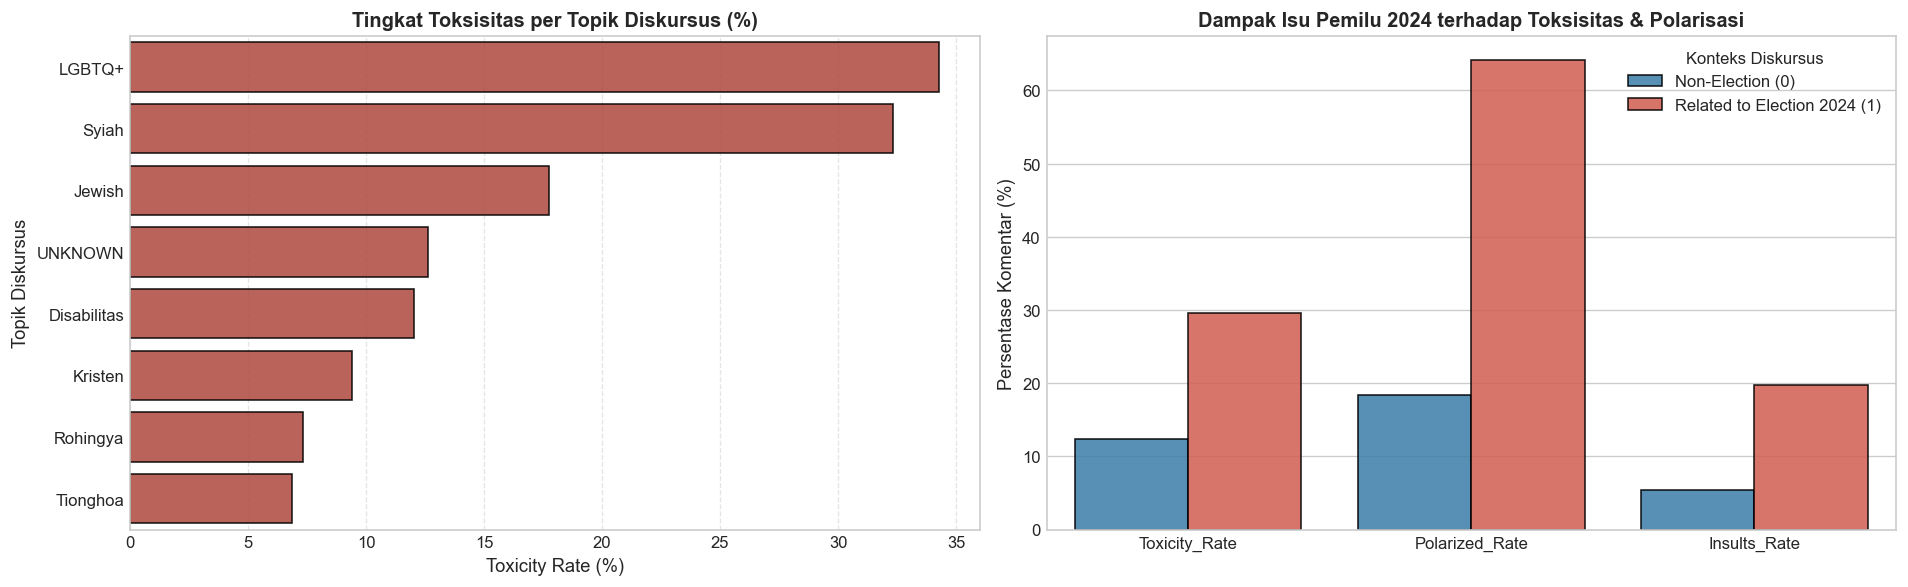

In [7]:
# 4.1 Distribusi Toksisitas Berdasarkan Topik Diskursus Sosial-Politik
# Ambil topik utama (single & composite teratas)
top_topics = valid_df["topic"].value_counts().head(8).index
topic_cross = valid_df[valid_df["topic"].isin(top_topics)].groupby("topic").agg(
    Total_Komentar=("is_toxic", "count"),
    Toxicity_Rate=("is_toxic", lambda x: np.mean(x) * 100),
    Identity_Attack_Rate=("identity_attack_bin", lambda x: np.mean(x) * 100),
    Polarized_Rate=("polarized_bin", lambda x: np.mean(x) * 100)
).sort_values("Toxicity_Rate", ascending=False)

print("Tabel Kerentanan Toksisitas Berdasarkan Topik Diskursus:")
display(topic_cross.round(2))

# 4.2 Analisis Pengaruh Diskursus Pemilu 2024
valid_df["election_bin"] = valid_df["related_to_election_2024"].apply(lambda x: int(np.mean([int(v) for v in x]) >= 0.5))
election_tox = valid_df.groupby("election_bin").agg(
    Total_Komentar=("is_toxic", "count"),
    Toxicity_Rate=("is_toxic", lambda x: np.mean(x) * 100),
    Polarized_Rate=("polarized_bin", lambda x: np.mean(x) * 100),
    Insults_Rate=("insults_bin", lambda x: np.mean(x) * 100)
).rename(index={0: "Non-Election (0)", 1: "Related to Election 2024 (1)"})

print("\nPerbandingan Toksisitas & Polarisasi: Diskursus Pemilu vs Non-Pemilu:")
display(election_tox.round(2))

# 4.3 Analisis Noise / Spam Text
valid_df["noise_bin"] = valid_df["is_noise_or_spam_text"].apply(lambda x: int(np.mean([int(v) for v in x]) >= 0.5))
noise_cross = pd.crosstab(valid_df["noise_bin"], valid_df["is_toxic"], normalize="index").rename(index={0: "Normal Text (0)", 1: "Noise/Spam (1)"}) * 100
noise_cross.columns = ["Non-Toxic (%)", "Toxic (%)"]
print("\nDistribusi Toksisitas pada Teks Noise/Spam:")
display(noise_cross.round(2))

# Visualisasi Silang Metadata
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Topic vs Toxicity
sns.barplot(data=topic_cross.reset_index(), y="topic", x="Toxicity_Rate", color="#c0392b", edgecolor="black", ax=axes[0], alpha=0.85)
axes[0].set_title("Tingkat Toksisitas per Topik Diskursus (%)", fontweight="bold")
axes[0].set_xlabel("Toxicity Rate (%)")
axes[0].set_ylabel("Topik Diskursus")
axes[0].grid(axis="x", linestyle="--", alpha=0.5)

# Plot Election Impact
election_plot_df = election_tox[["Toxicity_Rate", "Polarized_Rate", "Insults_Rate"]].reset_index()
election_melted = election_plot_df.melt(id_vars="election_bin", var_name="Metrik", value_name="Persentase")
sns.barplot(data=election_melted, x="Metrik", y="Persentase", hue="election_bin", palette=["#2980b9", "#e74c3c"], ax=axes[1], edgecolor="black", alpha=0.85)
axes[1].set_title("Dampak Isu Pemilu 2024 terhadap Toksisitas & Polarisasi", fontweight="bold")
axes[1].set_ylabel("Persentase Komentar (%)")
axes[1].set_xlabel("")
axes[1].legend(title="Konteks Diskursus")

plt.tight_layout()
plt.show()


**Interpretasi 4.1:** Metadata diskursus memperlihatkan pola yang sangat mencolok:
1. **Topik Paling Rawan:** Isu seputar *LGBTQ+* (34.28%) dan *Syiah* (32.33%) memiliki tingkat toksisitas dan serangan identitas tertinggi, jauh melampaui rata-rata baseline (14.04%).
2. **Dampak Pemilu 2024:** Diskursus yang berkaitan dengan Pemilu 2024 memicu lonjakan toksisitas **2.4x lipat (29.61% vs 12.30%)** dan lonjakan polarisasi publik hingga **3.5x lipat (64.21% vs 18.39%)**.

## 5. Karakteristik Teks, Fitur Linguistik, & Analisis N-Gram
Di bagian ini, kita menganalisis:
1. Statistik deskriptif panjang kata dan karakter antar kelas (dengan visualisasi outlier).
2. Fitur gaya penulisan media sosial (*stylistic features*): rasio huruf kapital (*capslock*) dan repetisi tanda baca.
3. Analisis kata pembeda kuat (*unigram relative risk*).
4. **Analisis Frasa Multi-Kata (Top Bigrams & Trigrams)** untuk menangkap konteks ujaran kebencian.


--- Statistik Karakteristik Linguistik per Kelas ---


,word_count_raw,char_count_raw,caps_ratio,exclam_count
is_toxic,,,,
Non-Toxic (0),45.113,319.669,0.111,0.210
Toxic (1),36.465,250.634,0.116,0.318


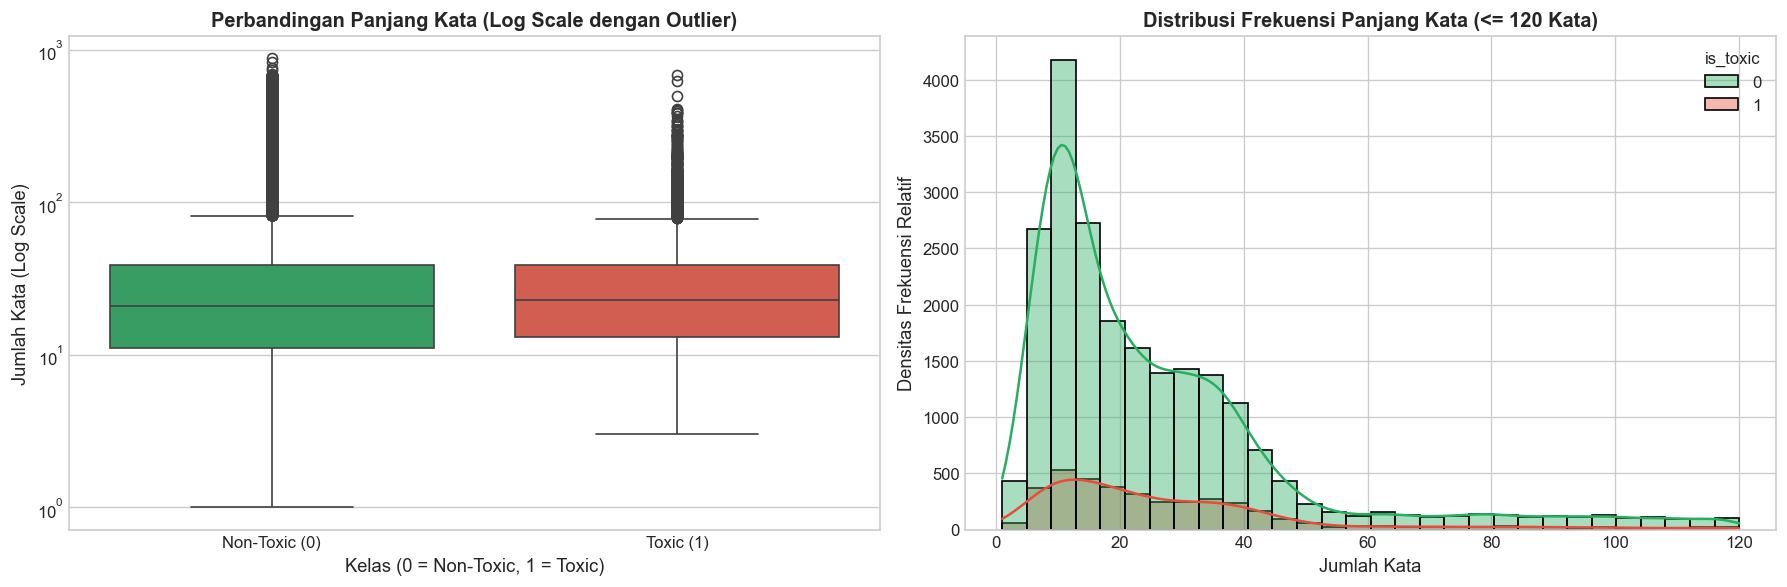


Top 10 Bigram (Frasa 2 Kata) per Kelas:


,Bigram Toxic,Freq (Toxic),Bigram Non-Toxic,Freq (Non-Toxic)
0,zionis israel,171,pengungsi rohingya,1604
1,cacat hukum,96,rumah sakit,762
2,jalur gaza,90,jalur gaza,726
3,rumah sakit,85,banda aceh,720
4,umat islam,71,warga palestina,459
5,kaum muslimin,69,serangan israel,432
6,warga sipil,67,asian games,397
7,warga palestina,63,ganjar pranowo,391
8,rakyat palestina,53,israel palestina,391
9,cawapres cacat,51,etnis rohingya,381



Top 10 Trigram (Frasa 3 Kata) Kelas Toksik:


,Trigram Toxic,Freq (Toxic)
0,cawapres cacat hukum,46
1,syaikhul islam ibnu,18
2,islam ibnu taimiyah,18
3,ali bin abi,17
4,nabi shallallahu alahi,16
5,shallallahu alahi sallam,16
6,mendukung agresi israel,15
7,muhammad bin abdul,15
8,ibnu taimiyah rahimahullahu,15
9,bin abi thalib,14


In [8]:
# 5.1 Statistik Deskriptif & Stylistic Features
valid_df["caps_ratio"] = valid_df["text"].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / max(1, len(str(x))))
valid_df["exclam_count"] = valid_df["text"].apply(lambda x: str(x).count("!"))
valid_df["question_count"] = valid_df["text"].apply(lambda x: str(x).count("?"))

print("--- Statistik Karakteristik Linguistik per Kelas ---")
ling_stats = valid_df.groupby("is_toxic")[["word_count_raw", "char_count_raw", "caps_ratio", "exclam_count"]].mean().rename(index={0: "Non-Toxic (0)", 1: "Toxic (1)"})
display(ling_stats.round(3))

# 5.2 Visualisasi Distribusi Panjang Teks (Boxplot Outlier & KDE)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot dengan fliers (menampilkan outlier ekstrem)
sns.boxplot(
    data=valid_df, x="is_toxic", y="word_count_raw",
    palette=["#27ae60", "#e74c3c"], ax=axes[0], showfliers=True
)
axes[0].set_yscale("log")
axes[0].set_title("Perbandingan Panjang Kata (Log Scale dengan Outlier)", fontweight="bold")
axes[0].set_xlabel("Kelas (0 = Non-Toxic, 1 = Toxic)")
axes[0].set_ylabel("Jumlah Kata (Log Scale)")
axes[0].set_xticklabels(["Non-Toxic (0)", "Toxic (1)"])

# Histogram & KDE
sns.histplot(
    data=valid_df[valid_df["word_count_raw"] <= 120],
    x="word_count_raw", hue="is_toxic",
    kde=True, common_norm=False, bins=30,
    palette=["#27ae60", "#e74c3c"], ax=axes[1], alpha=0.4
)
axes[1].set_title("Distribusi Frekuensi Panjang Kata (<= 120 Kata)", fontweight="bold")
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_ylabel("Densitas Frekuensi Relatif")

plt.tight_layout()
plt.show()

# 5.3 Analisis Kata Pembeda Kuat & N-Gram (Bigram/Trigram)
indo_stopwords = set(stopwords.words("indonesian"))
informal_stops = {
    "yg", "dg", "dgn", "ny", "d", "klo", "kalo", "kl", "utk", "tp", "bgt",
    "ya", "aja", "nih", "deh", "sih", "dong", "kan", "tuh", "nya", "amp",
    "rt", "si", "gue", "gw", "lu", "lo", "elu", "elo", "ku", "mu", "ini", "itu",
    "ada", "bisa", "udah", "sudah", "jadi",
    "sama", "juga", "dari", "pada", "ke", "di", "dan", "atau", "para", "kamu", "orang"
}
# KATA NEGASI WAJIB DIPERTAHANKAN (NEGATION PRESERVATION)
# Menghapus kata negasi akan membalikkan makna kalimat 180 derajat (misal: "tidak rasis" -> "rasis", "tidak terorisme" -> "terorisme")
negation_words = {
    "tidak", "tak", "bukan", "jangan", "tanpa", "belum", "tiada",
    "ga", "gak", "nggak", "gk", "tdk", "bkn", "kagak", "kaga"
}
custom_stopwords = (indo_stopwords.union(informal_stops)) - negation_words

def get_ngrams(text, n=1):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+|@\w+|#\w+|&\w+;", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    tokens = [w for w in text.split() if w not in custom_stopwords and len(w) > 2]
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

# Bigrams
toxic_bigrams = [bg for t in valid_df[valid_df["is_toxic"] == 1]["text"] for bg in get_ngrams(t, 2)]
nontoxic_bigrams = [bg for t in valid_df[valid_df["is_toxic"] == 0]["text"] for bg in get_ngrams(t, 2)]

top10_tox_bi = pd.DataFrame(Counter(toxic_bigrams).most_common(10), columns=["Bigram Toxic", "Freq (Toxic)"])
top10_nontox_bi = pd.DataFrame(Counter(nontoxic_bigrams).most_common(10), columns=["Bigram Non-Toxic", "Freq (Non-Toxic)"])

print("\nTop 10 Bigram (Frasa 2 Kata) per Kelas:")
display(pd.concat([top10_tox_bi, top10_nontox_bi], axis=1))

# Trigrams
toxic_trigrams = [tg for t in valid_df[valid_df["is_toxic"] == 1]["text"] for tg in get_ngrams(t, 3)]
top10_tox_tri = pd.DataFrame(Counter(toxic_trigrams).most_common(10), columns=["Trigram Toxic", "Freq (Toxic)"])
print("\nTop 10 Trigram (Frasa 3 Kata) Kelas Toksik:")
display(top10_tox_tri)


**Interpretasi 5.1:** Analisis N-Gram mengungkap wawasan semantik yang tidak terlihat pada unigram tunggal:
1. **Senjatisasi Istilah (*Weaponized Terminology*):** Frasa seperti *"cawapres cacat hukum"* membuktikan bahwa istilah disabilitas (*cacat*) diinstrumentalisasi dalam serangan politik Pilpres 2024.
2. **Konteks Frasa vs Kata Tunggal:** Istilah agama/sektarian seperti *syiah* muncul pada teks non-toksik dalam konteks institusi netral (*"universitas syiah kuala"*), sedangkan pada teks toksik muncul sebagai ujaran penyesatan/kebencian (*"syiah sesat"*, *"doktrin syiah"*). Ini menegaskan pentingnya pemodelan berbasis konteks urutan (*transformer*) dibanding Bag-of-Words sederhana.

## 6. Pembersihan Awal (Eksploratif) & Penanganan Kata Negasi
> **Catatan Metodologis & Peringatan Penting (*The Negation Inversion Pitfall*):**  
> Pembersihan tahap ini merupakan **Pembersihan Eksploratif Leksikal**. Salah satu jebakan paling fatal dalam pembersihan teks tugas deteksi toksisitas & analisis sentimen adalah **menghapus kata negasi (*tidak, bukan, jangan, gak, dll.*) sebagai stopword**.  
> *Contoh Kasus Nyata:* Kalimat berita netral *"Klaim bahwa sepanjang 2023 **tidak** terjadi aksi terorisme di Indonesia"* jika kata negasinya dihapus secara naif akan menyisakan *"klaim aksi terorisme indonesia"*, sehingga maknanya berbalik 180° menjadi terkesan bermuatan terorisme/kekerasan.  
> Oleh karena itu, pada pipeline ini seluruh **kata negasi wajib diproteksi dan dipertahankan (*Negation Preservation*)**.

Langkah-langkah pipeline cleaning eksploratif:
1. *Lowercasing* (penyeragaman huruf kecil)
2. Penghapusan URL dan tautan web
3. Penghapusan *mention* akun media sosial (`@user`)
4. Penghapusan *hashtag* (`#tag`)
5. Penghapusan entitas HTML sisa *scraping* (`&amp;`, dll)
6. Penghapusan emoji dan simbol non-ASCII
7. Normalisasi pemanjangan karakter (*word elongation*, misal: "suuuuudah" $\rightarrow$ "sudah")
8. Penghapusan derau angka
9. Penghapusan tanda baca
10. Penghapusan stopword Bahasa Indonesia **dengan proteksi kata negasi (*Negation-Preserving Stopwords*)**


In [9]:
# 6.1 Pipeline Fungsi Pembersihan Teks Eksploratif (Negation-Preserving)
def clean_text_exploratory(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    text = re.sub(r"&\w+;", " ", text)
    text = text.encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"(.)\1{2,}", r"\1", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    # Filter stopwords dengan mempertahankan kata negasi
    tokens = [w for w in text.split() if w not in custom_stopwords and len(w) > 2]
    return " ".join(tokens)

# Terapkan ke kolom baru 'clean_text' tanpa menimpa 'text' asli
valid_df["clean_text"] = valid_df["text"].apply(clean_text_exploratory)

# 6.2 Perbandingan Before vs After Pembersihan
print("Perbandingan Before vs After Pembersihan Eksploratif (Perhatikan Kata Negasi yang Dipertahankan):")
sample_comp = valid_df[["text_id", "is_toxic", "text", "clean_text"]].sample(4, random_state=123)
for idx, row in sample_comp.iterrows():
    lbl = "TOXIC (1)" if row["is_toxic"] == 1 else "NON-TOXIC (0)"
    print(f"\n[ID: {row['text_id']} | Label: {lbl}]")
    print(f"  BEFORE : {row['text']}")
    print(f"  AFTER  : {row['clean_text']}")


Perbandingan Before vs After Pembersihan Eksploratif (Perhatikan Kata Negasi yang Dipertahankan):

[ID: 2-10399 | Label: NON-TOXIC (0)]
  BEFORE : Hasil Pengeluaran Pasaran CHINA Hari Jumat , 15 September 2023 Prize 1️⃣ : 4638 Prize 2️⃣ : 6666 Prize 3️⃣ : 5479 Shio : HARIMAU Selamat kepada para pemenang jackpot.🙏🏻
  AFTER  : hasil pengeluaran pasaran china jumat september prize prize prize shio harimau selamat pemenang jackpot

[ID: 4-571 | Label: NON-TOXIC (0)]
  BEFORE : Benar, Klaim Ganjar Pranowo Bahwa Sepanjang 2023 Tidak Terjadi Aksi Terorisme di Indonesia
  AFTER  : klaim ganjar pranowo tidak aksi terorisme indonesia

[ID: 4-1937 | Label: NON-TOXIC (0)]
  BEFORE : Video Serangan Petani Kulit Putih di Afrika Selatan
  AFTER  : video serangan petani kulit putih afrika selatan

[ID: 4-3492 | Label: TOXIC (1)]
  BEFORE : @the0ka @shimclover @JackVardan Rasulullah shallallahu ‘alaihi wa sallam bersabda (artinya) "Akan mengikuti Dajjal tujuh puluh ribu orang Yahudi Asfahan, mereka mem

**Interpretasi 6.1:** Pipeline pembersihan eksploratif secara efektif melenyapkan noise media sosial seperti tautan eksternal, mention akun, emoji, dan elongasi karakter tanpa merusak polaritas semantik. Dengan diterapkannya **proteksi kata negasi (*negation preservation*)**, kalimat seperti *"tidak terjadi aksi terorisme"* tetap mempertahankan kata *"tidak"* sehingga maknanya tidak berbalik arah.

## 7. Visualisasi Komprehensif Hasil EDA
Pada tahap ini, kita menyajikan rangkuman visual komprehensif:
1. Word Cloud terpisah untuk kelas Toksik vs Tidak Toksik (menggunakan `clean_text`).
2. Top-15 Bar Chart kata paling dominan per kelas.
3. Top-15 Bar Chart kata pembeda kuat (*Relative Risk Ratio*).


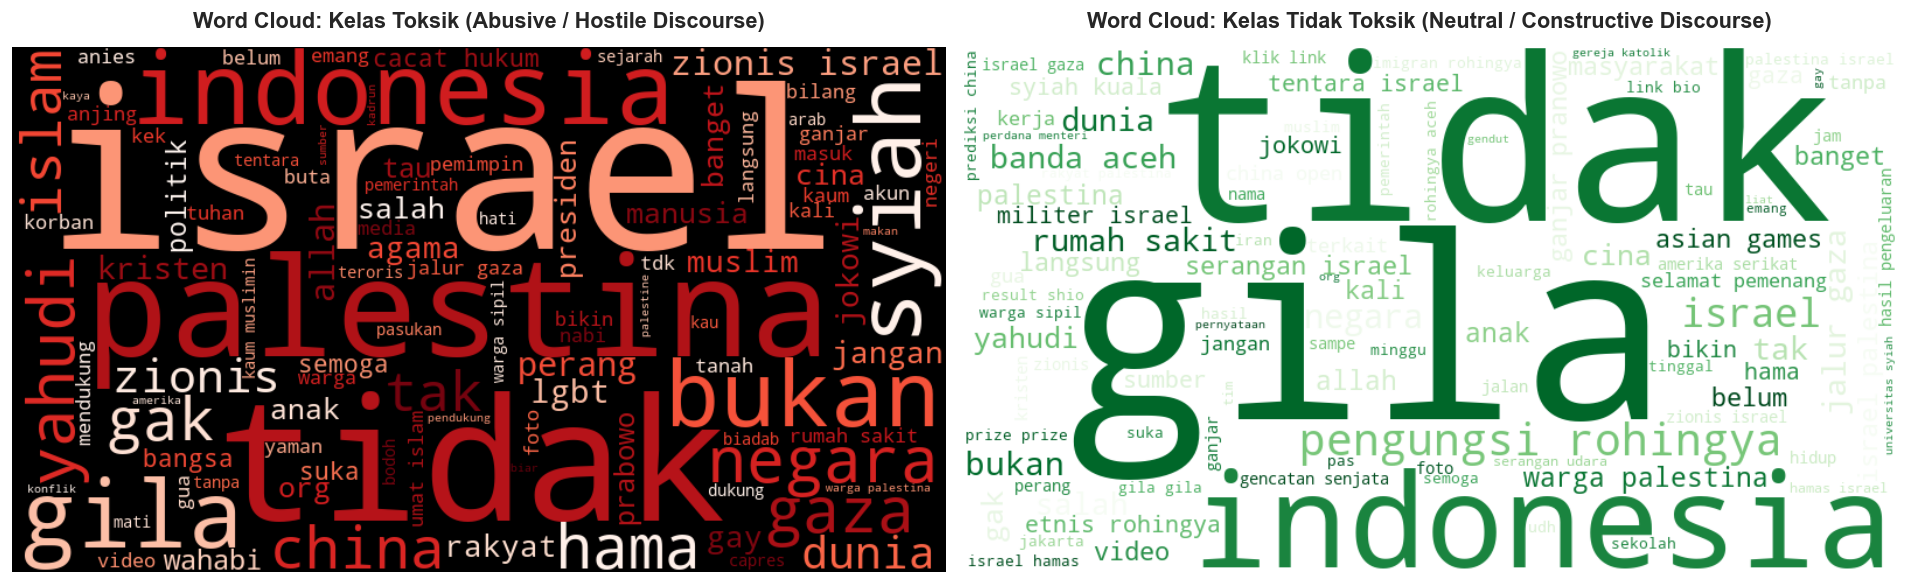

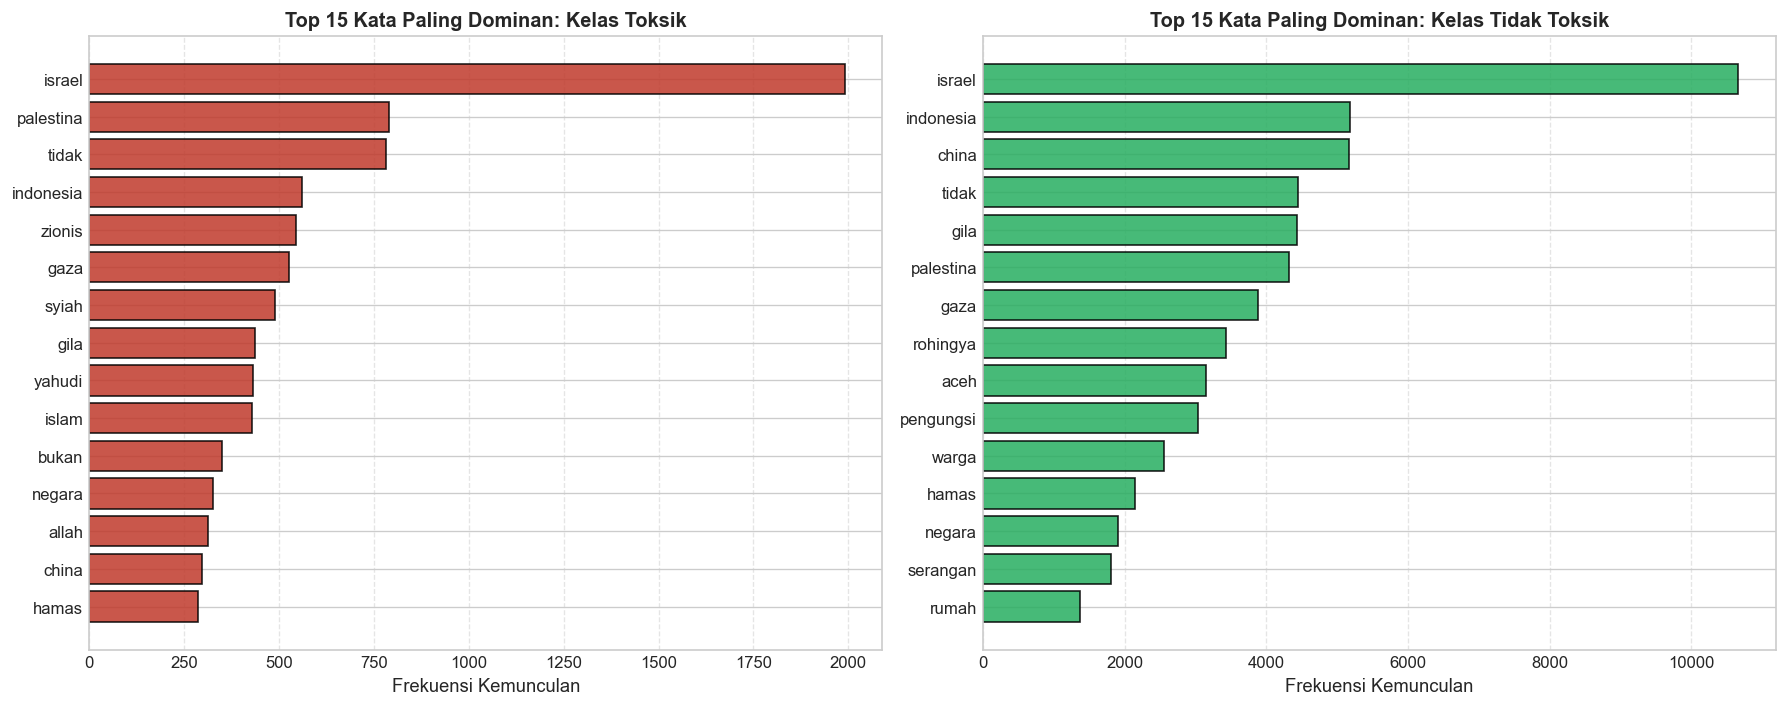

Top 15 Kata Pembeda Kuat Kelas Toksik (Minimal 20 kemunculan):


,Kata,Frekuensi Toxic,Frekuensi Non-Toxic,Rasio Kecondongan Toxic (Relative Risk)
718,kontol,23,3,43.488261
729,rahimahullahu,21,3,39.706673
728,syaikhul,20,3,37.815879
694,taimiyah,21,4,31.765339
351,bego,25,5,31.513233
683,pengecut,30,8,25.210586
57,kadrun,66,22,21.703026
724,rafidhah,50,17,21.008822
723,kesesatan,26,9,19.664257
425,pesek,61,23,19.223072


In [10]:
# 7.1 Visualisasi Word Cloud Terpisah untuk Kelas Toksik vs Non-Toksik
corpus_toxic = " ".join(valid_df[valid_df["is_toxic"] == 1]["clean_text"])
corpus_nontoxic = " ".join(valid_df[valid_df["is_toxic"] == 0]["clean_text"])

wc_tox = WordCloud(
    width=800, height=450, background_color="black", colormap="Reds",
    max_words=100, contour_width=1, contour_color="red"
).generate(corpus_toxic)

wc_nontox = WordCloud(
    width=800, height=450, background_color="white", colormap="Greens",
    max_words=100, contour_width=1, contour_color="darkgreen"
).generate(corpus_nontoxic)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(wc_tox, interpolation="bilinear")
axes[0].set_title("Word Cloud: Kelas Toksik (Abusive / Hostile Discourse)", fontsize=13, fontweight="bold", pad=12)
axes[0].axis("off")

axes[1].imshow(wc_nontox, interpolation="bilinear")
axes[1].set_title("Word Cloud: Kelas Tidak Toksik (Neutral / Constructive Discourse)", fontsize=13, fontweight="bold", pad=12)
axes[1].axis("off")

plt.tight_layout()
plt.show()

# 7.2 Top-15 Bar Chart Kata Paling Sering Muncul per Kelas
top15_tox = pd.DataFrame(Counter(corpus_toxic.split()).most_common(15), columns=["Kata", "Frekuensi"]).sort_values("Frekuensi", ascending=True)
top15_nontox = pd.DataFrame(Counter(corpus_nontoxic.split()).most_common(15), columns=["Kata", "Frekuensi"]).sort_values("Frekuensi", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(top15_tox["Kata"], top15_tox["Frekuensi"], color="#c0392b", edgecolor="black", alpha=0.85)
axes[0].set_title("Top 15 Kata Paling Dominan: Kelas Toksik", fontweight="bold")
axes[0].set_xlabel("Frekuensi Kemunculan")
axes[0].grid(axis="x", linestyle="--", alpha=0.5)

axes[1].barh(top15_nontox["Kata"], top15_nontox["Frekuensi"], color="#27ae60", edgecolor="black", alpha=0.85)
axes[1].set_title("Top 15 Kata Paling Dominan: Kelas Tidak Toksik", fontweight="bold")
axes[1].set_xlabel("Frekuensi Kemunculan")
axes[1].grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 7.3 Highlight Kata Pembeda Kuat (Relative Risk Ratio / Odds Ratio)
cnt_tox = Counter(corpus_toxic.split())
cnt_nontox = Counter(corpus_nontoxic.split())
n_tox_words = len(corpus_toxic.split())
n_nontox_words = len(corpus_nontoxic.split())

discriminators = []
min_count = 20

for word, count_t in cnt_tox.items():
    if count_t >= min_count:
        freq_t = count_t / n_tox_words
        count_nt = cnt_nontox.get(word, 0)
        freq_nt = (count_nt + 1) / n_nontox_words
        ratio = freq_t / freq_nt
        discriminators.append({
            "Kata": word,
            "Frekuensi Toxic": count_t,
            "Frekuensi Non-Toxic": count_nt,
            "Rasio Kecondongan Toxic (Relative Risk)": ratio
        })

discrim_table = pd.DataFrame(discriminators).sort_values("Rasio Kecondongan Toxic (Relative Risk)", ascending=False)
print(f"Top 15 Kata Pembeda Kuat Kelas Toksik (Minimal {min_count} kemunculan):")
display(discrim_table.head(15))


**Interpretasi 7.1:** Visualisasi Word Cloud dan Top-15 Bar Chart memperlihatkan divergensi leksikal: pada kelas toksik muncul istilah penyerangan (*zionis*, *yahudi*, *syiah*, *gila*, *anjing*), sedangkan pada kelas non-toksik kosakata terfokus pada entitas geografis dan kemanusiaan (*indonesia*, *china*, *palestina*, *pengungsi*, *rohingya*, *aceh*). Metrik *Relative Risk* menyaring leksikon makian vulgar (*kontol*, *tolol*, *bego*, *kadrun*) yang memiliki risiko kemunculan puluhan kali lebih tinggi pada teks toksik.

## 8. Kesimpulan Terintegrasi & Rekomendasi Senior Data Scientist

Berdasarkan rangkaian Exploratory Data Analysis (EDA) komprehensif yang telah diperkaya pada dataset IndoDiscourse, berikut adalah kesimpulan terstruktur serta rekomendasi strategis sebelum melangkah ke tahap *machine learning modeling*:

---

### 1. Ringkasan Kondisi Dataset & Kualitas Anotasi
* **Dimensi & Profiling:** Dataset terdiri dari 28.448 baris dan 14 kolom, dianotasi oleh 29 anotator dengan sebaran latar belakang demografis yang luas.
* **Duplikasi & Konflik Label:** Ditemukan 2.274 teks duplikat murni (7.99%) yang mencakup **343 teks unik (742 baris) dengan label Majority Vote yang saling kontradiktif**.
* **Reliabilitas Anotasi & Tie-Vote:** Terdapat **1.839 baris teks dengan voting seri 50:50 (*tie-vote* $= 0.5$)**. Jika ambang batas dinaikkan menjadi *strict majority* ($> 0.5$), jumlah data toksik berkurang dari 3.995 menjadi 2.156 baris.

### 2. Tingkat Class Imbalance & Implikasi Pemodelan
* **Rasio Imbalance:** Pada target utama `toxicity`, rasio ketidakseimbangan kelas adalah **6.12 : 1** (14.04% toksik vs 85.96% non-toksik), dengan tingkat kelangkaan ekstrem pada sub-label seperti `sexually_explicit` (0.43%) dan `threat_incitement_to_violence` (2.76%).
* **Metrik Evaluasi Wajib:** **Akurasi standar dilarang keras** dijadikan acuan. Metrik utama pemodelan adalah **Macro F1-score**, **PR-AUC (Precision-Recall Area Under Curve)**, dan *Recall* pada kelas minoritas berisiko tinggi.
* **Strategi Penanganan Imbalance:**
  - Gunakan **Iterative Stratified K-Fold** berbasis multi-label untuk menjamin distribusi sub-label minoritas seimbang di setiap fold.
  - Terapkan **Class-Weighted Cross-Entropy Loss** atau **Focal Loss** ($\gamma pprox 2.0$) untuk memberikan penalti proporsional pada kelas minoritas tanpa distorsi data sintetis.

### 3. Temuan Metadata Sosial-Politik & N-Gram Linguistik
* **Kerentanan Topik:** Isu minoritas seperti *LGBTQ+* (34.28%) dan *Syiah* (32.33%) memiliki tingkat toksisitas tertinggi.
* **Katalis Pemilu 2024:** Diskursus Pemilu 2024 melipatgandakan toksisitas (29.61%) dan polarisasi (64.21%), dengan temuan instrumentalisasi frasa seperti *"cawapres cacat hukum"*.
* **Pembeda Kontekstual (N-Gram):** Kata-kata sensitif (misal: *syiah*, *tionghoa*) membutuhkan pemahaman urutan kata dan konteks kalimat (*transformer attention*) untuk membedakan nama institusi netral (*"universitas syiah kuala"*) vs ujaran kebencian sektarian.

### 4. Rekomendasi Rencana Aksi Pemodelan (Actionable Pipeline)
1. **Resolusi Konflik & Deduplikasi Data:** Bersihkan 343 teks duplikat berlabel kontradiktif dengan menerapkan aturan agregasi voting atau filtering sebelum partisi data train-test guna mencegah *data leakage*.
2. **Preprocessing Spesifik Arsitektur:**
   - **Model Transformer (IndoBERT / IndoRoBERTa):** Pertahankan tanda baca, tanda seru berulang, dan kapitalisasi (CAPSLOCK) karena memuat sinyal emosi permusuhan yang kuat. Gunakan `max_seq_length = 128` atau `256` token.
   - **Model Baseline (TF-IDF + Linear SVM / XGBoost):** Gunakan *cleaning* leksikal terstandarisasi dengan penambahan kamus normalisasi kata gaul/slang Indonesia.
3. **Multi-label Hierarchy Enforcement:** Perbaiki 482 baris inkonsistensi hierarki dengan logika post-processing: jika salah satu sub-label toksisitas aktif ($= 1$), maka target `toxicity` otomatis bernilai $1$.
4. **Penyimpanan Artefak Bersih:** Simpan data hasil preprocessing dan partisi ke dalam folder `data/processed/` (e.g. `train.parquet`, `val.parquet`, `test.parquet`) dengan format Parquet untuk efisiensi I/O tinggi.

---
